In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option("display.max_columns", None)

In [ ]:
df = pd.read_csv("final_hateXplain.csv")

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20109 entries, 0 to 20108
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   comment             20109 non-null  object
 1   label               20109 non-null  object
 2   Race                20109 non-null  object
 3   Religion            20109 non-null  object
 4   Gender              20109 non-null  object
 5   Sexual Orientation  20109 non-null  object
 6   Miscellaneous       3533 non-null   object
dtypes: object(7)
memory usage: 1.1+ MB


In [7]:
df.columns

Index(['comment', 'label', 'Race', 'Religion', 'Gender', 'Sexual Orientation',
       'Miscellaneous'],
      dtype='object')

In [8]:
df.isnull().sum()

comment                   0
label                     0
Race                      0
Religion                  0
Gender                    0
Sexual Orientation        0
Miscellaneous         16576
dtype: int64

In [9]:
print(df.shape)

(20109, 7)


In [10]:
df = df.drop_duplicates()

In [11]:
df["label"].value_counts()

label
normal        7818
hatespeech    6484
offensive     5807
Name: count, dtype: int64

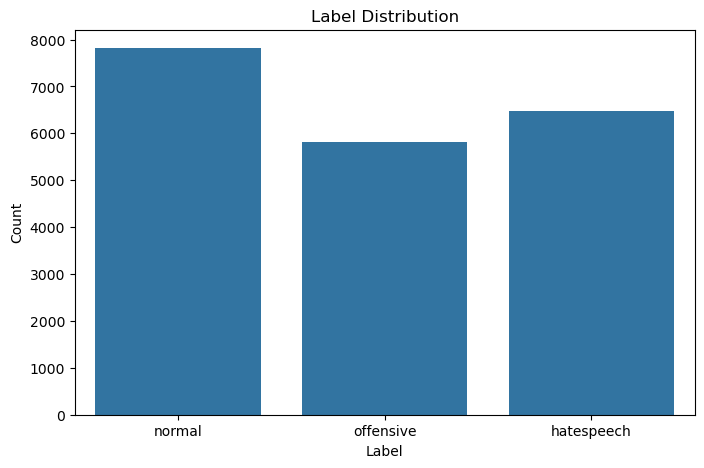

In [12]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="label"
)

plt.title("Label Distribution")

plt.xlabel("Label")

plt.ylabel("Count")

plt.show()

In [13]:
df["word_count"] = df["comment"].apply(
    lambda x: len(str(x).split())
)

In [14]:
df.head()

,comment,label,Race,Religion,Gender,Sexual Orientation,Miscellaneous,word_count
0,0 u0 lmao wow fuck you too 😂 😂,normal,No_race,Nonreligious,No_gender,No_orientation,NaN,9
1,1 0 th floor maybe wow cnn with the fakenews t...,offensive,No_race,Nonreligious,No_gender,No_orientation,Other,47
2,1 0 yrs <number> white women raped by niggers ...,hatespeech,African,Nonreligious,No_gender,No_orientation,NaN,23
3,1 2 h ago ching chong accepted your friend req...,offensive,Asian,Nonreligious,No_gender,No_orientation,NaN,11
4,1 8 th century mayhem and lawlessness had noth...,normal,No_race,Nonreligious,No_gender,No_orientation,NaN,47


In [15]:
df.groupby("label")["word_count"].mean()

label
hatespeech    24.888803
normal        23.362369
offensive     22.477527
Name: word_count, dtype: float64

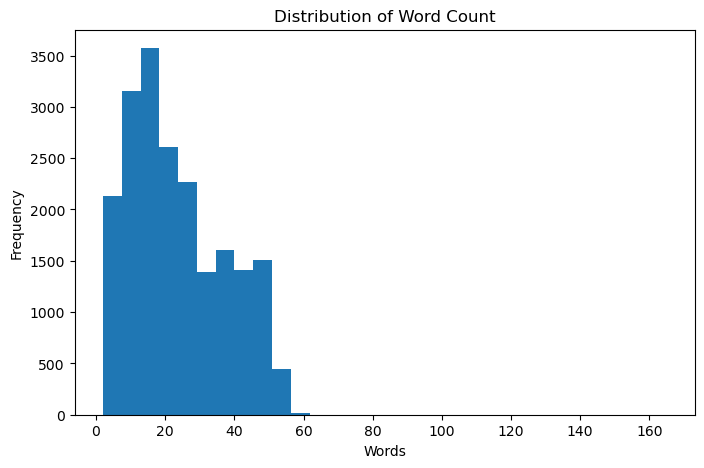

In [16]:
plt.figure(figsize=(8,5))

plt.hist(
    df["word_count"],
    bins=30
)

plt.xlabel("Words")

plt.ylabel("Frequency")

plt.title("Distribution of Word Count")

plt.show()

In [17]:
df["char_count"] = df["comment"].apply(len)

In [18]:
df[["word_count","char_count"]].describe()

,word_count,char_count
count,20109.000000,20109.000000
mean,23.599035,127.406833
std,13.815866,78.101560
min,2.000000,8.000000
25%,12.000000,63.000000
50%,21.000000,109.000000
75%,34.000000,185.000000
max,165.000000,526.000000


In [19]:
df.groupby("label")["char_count"].mean()

label
hatespeech    134.712677
normal        126.203249
offensive     120.869640
Name: char_count, dtype: float64

In [ ]:
import sys
sys.path.append("../src")
from preprocess import clean_text
import pandas as pd
df = pd.read_csv("final_hateXplain.csv")
df["clean_comment"] = df["comment"].apply(clean_text)
df.to_csv("cleaned_data.csv", index=False)
print("Saved Successfully!")

[nltk_data] Downloading package stopwords to C:\Users\EMAN
[nltk_data]     TAHIR\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to C:\Users\EMAN
[nltk_data]     TAHIR\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


Saved Successfully!


In [ ]:
sys.path.append("src")
from preprocess import clean_text

[nltk_data] Downloading package stopwords to C:\Users\EMAN
[nltk_data]     TAHIR\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.
[nltk_data] Downloading package wordnet to C:\Users\EMAN
[nltk_data]     TAHIR\AppData\Roaming\nltk_data...


In [21]:
df["clean_comment"] = df["comment"].apply(clean_text)

In [23]:
df[["comment", "clean_comment"]].tail()

,comment,clean_comment
20104,😂 😂 😂 😂 😂 y ’ all be so mad at caucasians fail...,😂 😂 😂 😂 😂 ’ mad caucasian failing forget black...
20105,🤔 🤔 🤔 🤔 mmm yes the trebuchet memes are much n...,🤔 🤔 🤔 🤔 mmm yes trebuchet meme much nicer cata...
20106,🤣 this so ghetto i ’ m ready to get tf,🤣 ghetto ’ ready get tf
20107,🤣 🤣 😂 😂 🤣 🤣 😂 😂 🤣 🤣 you spelled my name wrong ...,🤣 🤣 😂 😂 🤣 🤣 😂 😂 🤣 🤣 spelled name wrong name li...
20108,🤨 hm six million but yep they were disarmed ce...,🤨 hm six million yep disarmed ceppin one warsa...
